In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("healthcare_cleaned.csv")


print("Dataset shape:", df.shape)
df.head()


Dataset shape: (54860, 22)


,Patient_Name,Age,Gender,Blood_Type,Medical_Condition,Admission_Date,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results,Length_of_Stay,Age_Group,Recovery_Flag,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Year_Month
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,19-30,1,2024,1,January,2024-01
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,61-75,0,2019,8,August,2019-08
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,76+,1,2022,9,September,2022-09
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,19-30,0,2020,11,November,2020-11
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,31-45,0,2022,9,September,2022-09


## 1. KPI Summary

In [2]:
total_patients = len(df)
recovery_rate = df["Recovery_Flag"].mean() * 100
average_treatment_cost = df["Billing_Amount"].mean()
average_length_of_stay = df["Length_of_Stay"].mean()
total_hospitals = df["Hospital"].nunique()
total_doctors = df["Doctor"].nunique()

print("Total Patients:", total_patients)
print("Recovery Rate:", round(recovery_rate, 2), "%")
print("Average Treatment Cost:", round(average_treatment_cost, 2))
print("Average Length of Stay:", round(average_length_of_stay, 2), "days")
print("Total Hospitals:", total_hospitals)
print("Total Doctors:", total_doctors)


Total Patients: 54860
Recovery Rate: 33.36 %
Average Treatment Cost: 25594.63
Average Length of Stay: 15.5 days
Total Hospitals: 39815
Total Doctors: 40276


## 2. Patient Demographics — Gender

Gender
Male      27449
Female    27411
Name: count, dtype: int64


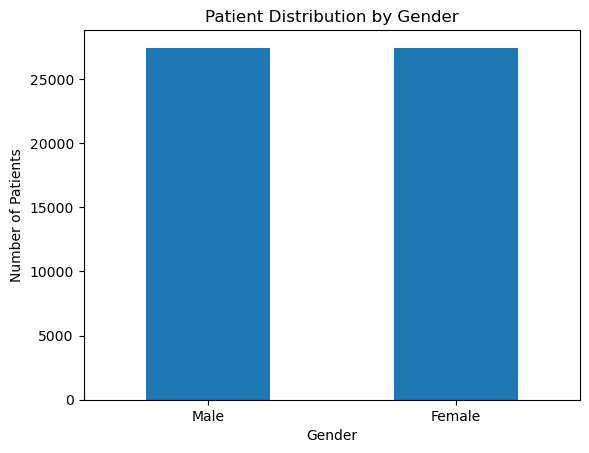

Gender
Male      50.03
Female    49.97
Name: proportion, dtype: float64


In [3]:
gender_counts = df["Gender"].value_counts()
print(gender_counts)

gender_counts.plot(kind="bar")
plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

print((df["Gender"].value_counts(normalize=True) * 100).round(2))


## 3. Patient Demographics — Age Groups

Age_Group
0-18       885
19-30     9504
31-45    12088
46-60    12248
61-75    12079
76+       8056
Name: count, dtype: int64


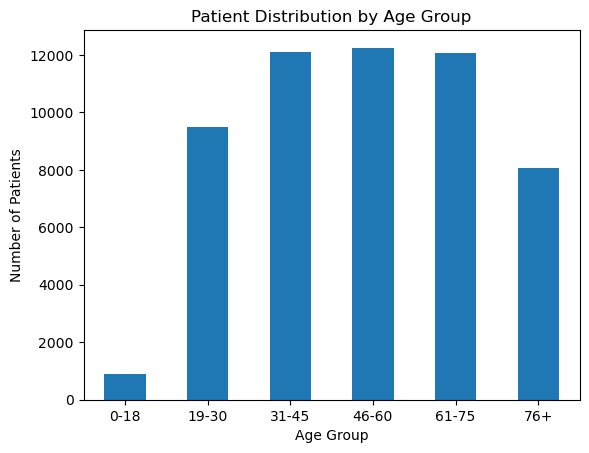

In [4]:
age_group_counts = df["Age_Group"].value_counts().sort_index()
print(age_group_counts)

age_group_counts.plot(kind="bar")
plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


## 4. Disease Analysis

Medical_Condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64


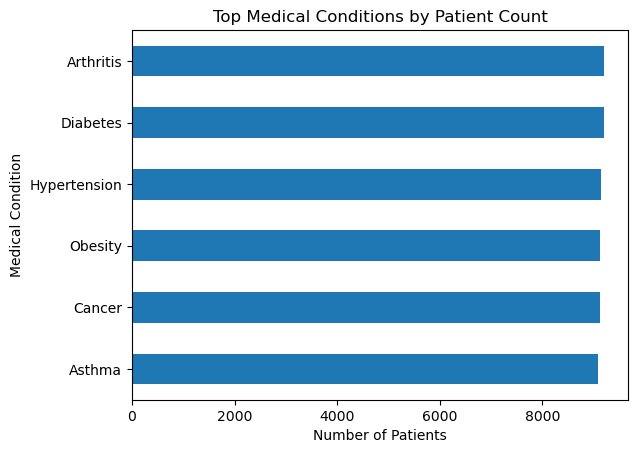

In [5]:
disease_counts = df["Medical_Condition"].value_counts()
print(disease_counts)

top_diseases = disease_counts.head(10)
top_diseases.sort_values().plot(kind="barh")
plt.title("Top Medical Conditions by Patient Count")
plt.xlabel("Number of Patients")
plt.ylabel("Medical Condition")
plt.show()


## 5. Treatment Cost Analysis

Average: 25594.63
Median: 25593.87
Minimum: 9.24
Maximum: 52764.28
Medical_Condition
Obesity         25859.215373
Diabetes        25714.326349
Asthma          25685.385020
Hypertension    25559.844868
Arthritis       25542.898356
Cancer          25205.924207
Name: Billing_Amount, dtype: float64


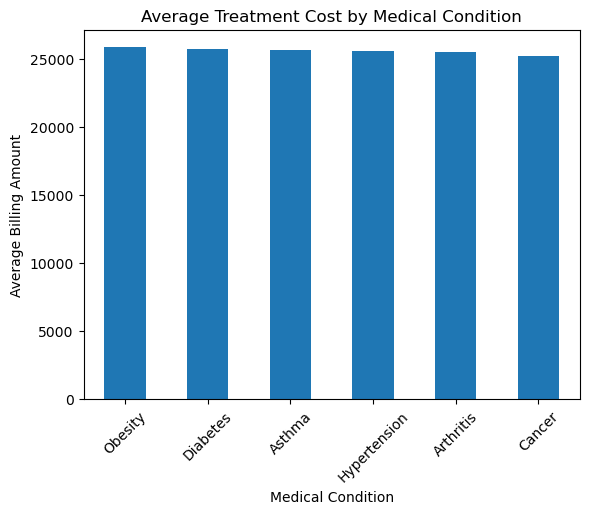

In [6]:
print("Average:", round(df["Billing_Amount"].mean(), 2))
print("Median:", round(df["Billing_Amount"].median(), 2))
print("Minimum:", round(df["Billing_Amount"].min(), 2))
print("Maximum:", round(df["Billing_Amount"].max(), 2))

cost_by_disease = (
    df.groupby("Medical_Condition")["Billing_Amount"]
    .mean()
    .sort_values(ascending=False)
)
print(cost_by_disease)

cost_by_disease.plot(kind="bar")
plt.title("Average Treatment Cost by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=45)
plt.show()


## 6. Recovery Rate Analysis

Overall Recovery Rate: 33.36 %
Medical_Condition
Asthma          34.295472
Hypertension    33.961231
Diabetes        33.260846
Obesity         33.143421
Cancer          33.011731
Arthritis       32.507874
Name: Recovery_Flag, dtype: float64


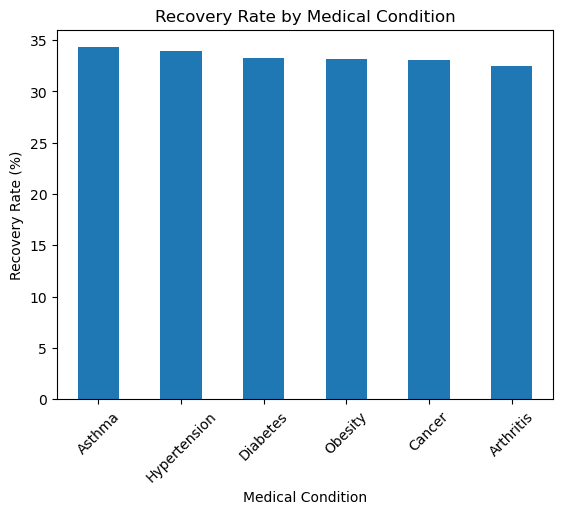

In [7]:
recovery_rate = df["Recovery_Flag"].mean() * 100
print("Overall Recovery Rate:", round(recovery_rate, 2), "%")

recovery_by_disease = (
    df.groupby("Medical_Condition")["Recovery_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(recovery_by_disease)

recovery_by_disease.plot(kind="bar")
plt.title("Recovery Rate by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Recovery Rate (%)")
plt.xticks(rotation=45)
plt.show()


## 7. Hospital Performance

In [8]:
hospital_analysis = (
    df.groupby("Hospital")
    .agg(
        Patient_Count=("Patient_Name", "count"),
        Average_Treatment_Cost=("Billing_Amount", "mean"),
        Average_Length_of_Stay=("Length_of_Stay", "mean"),
        Recovery_Rate=("Recovery_Flag", "mean")
    )
)

hospital_analysis["Recovery_Rate"] *= 100
hospital_analysis = hospital_analysis.round(2)

print(hospital_analysis.sort_values("Patient_Count", ascending=False).head(10))


             Patient_Count  Average_Treatment_Cost  Average_Length_of_Stay  \
Hospital                                                                     
LLC Smith               44                23413.41                   15.57   
Ltd Smith               39                25727.32                   16.51   
Smith Ltd               37                26217.19                   15.14   
Johnson PLC             37                29229.12                   16.14   
Smith PLC               36                28595.12                   17.64   
Smith Group             34                23728.47                   17.00   
Smith Inc               33                23401.71                   15.39   
Group Smith             32                28217.99                   16.31   
Smith LLC               32                22865.11                   16.09   
Johnson Inc             32                29279.10                   14.81   

             Recovery_Rate  
Hospital                    
LLC S

Hospital
Mcdaniel-Leach                    100.0
Mcdonald, Ferguson Cross and      100.0
Mcdonald-Davis                    100.0
Mcdonald-Bradley                  100.0
Mcdonald-Bennett                  100.0
Mcdonald-Barnes                   100.0
Mcdonald, Roberson and Sanchez    100.0
Mcdonald, Mason Cochran and       100.0
Mcdonald and Turner, Smith        100.0
Mcdonald-Ellis                    100.0
Name: Recovery_Flag, dtype: float64


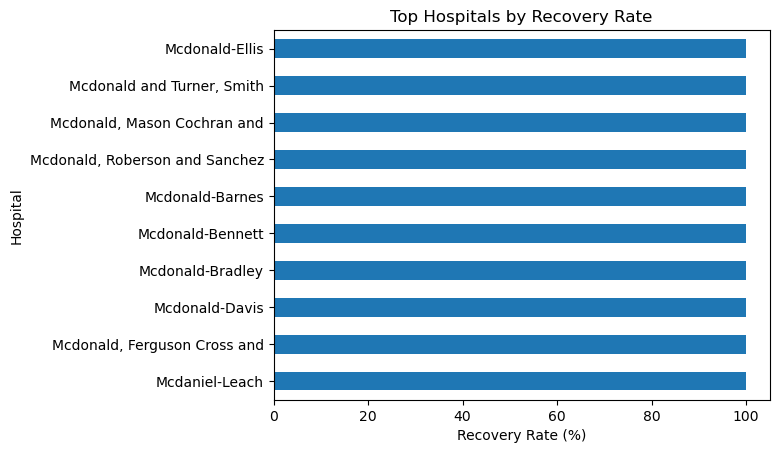

In [9]:
hospital_recovery = (
    df.groupby("Hospital")["Recovery_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(hospital_recovery.head(10))

hospital_recovery.head(10).sort_values().plot(kind="barh")
plt.title("Top Hospitals by Recovery Rate")
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Hospital")
plt.show()


## 8. Admission Pattern Analysis

Admission_Type
Elective     18437
Urgent       18353
Emergency    18070
Name: count, dtype: int64


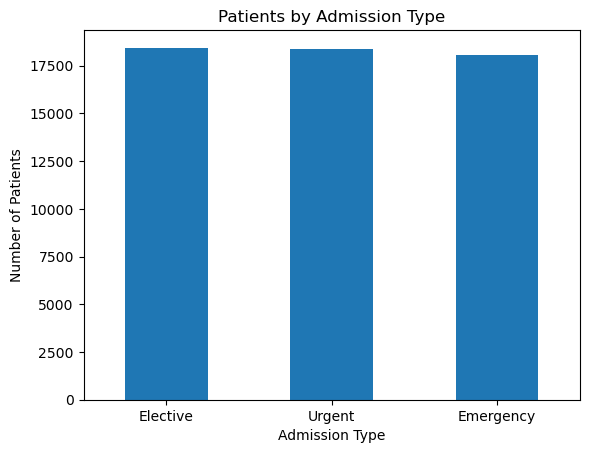

Admission_Type
Elective     33.61
Urgent       33.45
Emergency    32.94
Name: proportion, dtype: float64


In [10]:
admission_counts = df["Admission_Type"].value_counts()
print(admission_counts)

admission_counts.plot(kind="bar")
plt.title("Patients by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

print((df["Admission_Type"].value_counts(normalize=True) * 100).round(2))


## 9. Length of Stay Analysis

count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64
Average Length of Stay: 15.5 days


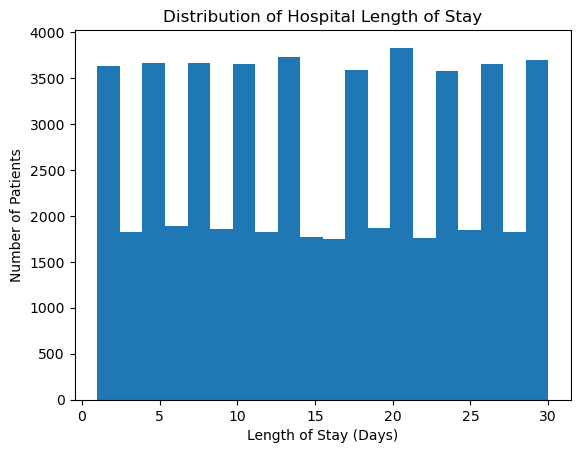

In [11]:
print(df["Length_of_Stay"].describe())
print("Average Length of Stay:", round(df["Length_of_Stay"].mean(), 2), "days")

plt.hist(df["Length_of_Stay"], bins=20)
plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")
plt.show()


## 10. Monthly Admission Trend

Admission_Year_Month
2019-05    672
2019-06    897
2019-07    950
2019-08    982
2019-09    924
          ... 
2024-01    903
2024-02    865
2024-03    900
2024-04    939
2024-05    212
Length: 61, dtype: int64


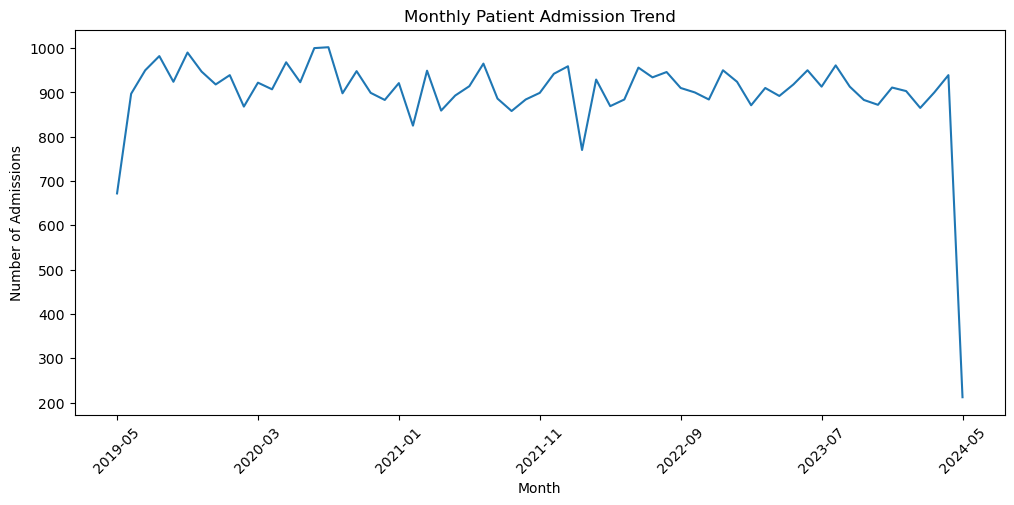

In [12]:
monthly_admissions = df.groupby("Admission_Year_Month").size()
print(monthly_admissions)

monthly_admissions.plot(kind="line", figsize=(12, 5))
plt.title("Monthly Patient Admission Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.show()


## 11. Doctor Performance

In [13]:
doctor_analysis = (
    df.groupby("Doctor")
    .agg(
        Patient_Count=("Patient_Name", "count"),
        Average_Treatment_Cost=("Billing_Amount", "mean"),
        Average_Length_of_Stay=("Length_of_Stay", "mean"),
        Recovery_Rate=("Recovery_Flag", "mean")
    )
)

doctor_analysis["Recovery_Rate"] *= 100
doctor_analysis = doctor_analysis.round(2)

display(
    doctor_analysis.sort_values("Patient_Count", ascending=False).head(10)
)


,Patient_Count,Average_Treatment_Cost,Average_Length_of_Stay,Recovery_Rate
Doctor,,,,
Michael Smith,27,29055.62,15.63,22.22
John Smith,22,27732.25,14.36,40.91
Robert Smith,21,29007.65,13.81,33.33
Michael Johnson,20,23040.95,18.70,65.00
David Smith,19,24912.93,15.32,36.84
James Smith,19,24313.35,17.68,26.32
Robert Johnson,19,27589.11,13.79,26.32
Michael Williams,18,17171.73,15.50,50.00
John Johnson,17,27457.06,18.06,35.29


## 12. Billing Outlier Analysis

In [14]:
Q1 = df["Billing_Amount"].quantile(0.25)
Q3 = df["Billing_Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

billing_outliers = df[
    (df["Billing_Amount"] < lower_bound) |
    (df["Billing_Amount"] > upper_bound)
]

print("Potential billing outliers:", len(billing_outliers))

display(
    df.nlargest(10, "Billing_Amount")[
        ["Patient_Name", "Medical_Condition", "Hospital",
         "Billing_Amount", "Length_of_Stay"]
    ]
)


Potential billing outliers: 0


,Patient_Name,Medical_Condition,Hospital,Billing_Amount,Length_of_Stay
36293,Todd Carrillo,Hypertension,Griffin Group,52764.276736,26
34559,Karen Kline,Cancer,Hernandez-Morton,52373.032374,14
51083,Karen Kline,Cancer,Hernandez-Morton,52373.032374,14
5725,David Sandoval,Hypertension,Sons and Bailey,52271.663747,9
7074,Kathryn Gonzales,Diabetes,Miller Ltd,52211.852966,1
1570,Brett Marshall,Asthma,PLC Garner,52181.837792,7
6651,Laurie Hood,Arthritis,Walker-Garcia,52170.036854,2
52448,Laurie Hood,Arthritis,Walker-Garcia,52170.036854,2
33069,Justin Clark,Cancer,Ruiz-Anthony,52154.237722,23
34314,Scott Powell,Cancer,George-Gonzalez,52102.240889,9


## 13. Descriptive Statistics and Correlation

,Age,Billing_Amount,Length_of_Stay
count,54860.000000,54860.000000,54860.000000
mean,51.533850,25594.633637,15.498815
std,19.605295,14175.867041,8.661357
min,13.000000,9.238787,1.000000
25%,35.000000,13299.747940,8.000000
50%,52.000000,25593.873000,15.000000
75%,68.000000,37847.066671,23.000000
max,89.000000,52764.276736,30.000000


,Age,Billing_Amount,Length_of_Stay
Age,1.000000,-0.003309,0.008022
Billing_Amount,-0.003309,1.000000,-0.004801
Length_of_Stay,0.008022,-0.004801,1.000000


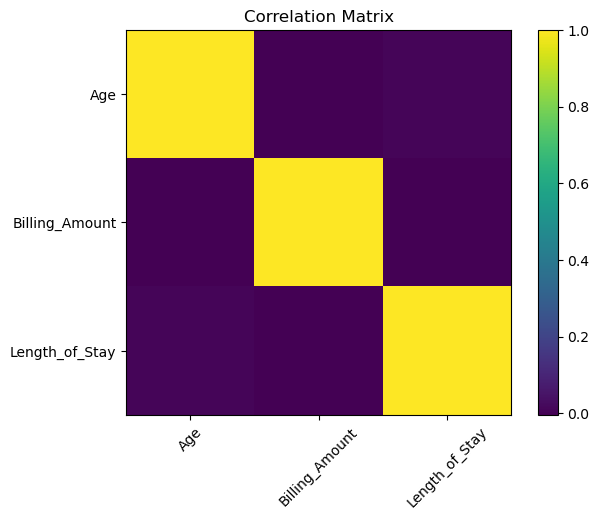

In [15]:
display(
    df[["Age", "Billing_Amount", "Length_of_Stay"]].describe()
)

correlation = df[
    ["Age", "Billing_Amount", "Length_of_Stay"]
].corr()

display(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()


## 14. Final KPI Table

In [16]:
kpi_data = {
    "Patient Count": len(df),
    "Recovery Rate (%)": df["Recovery_Flag"].mean() * 100,
    "Average Treatment Cost": df["Billing_Amount"].mean(),
    "Average Length of Stay": df["Length_of_Stay"].mean(),
    "Hospital Count": df["Hospital"].nunique(),
    "Doctor Count": df["Doctor"].nunique()
}

kpi_df = pd.DataFrame(kpi_data.items(), columns=["KPI", "Value"])
kpi_df["Value"] = kpi_df["Value"].round(2)

display(kpi_df)


,KPI,Value
0,Patient Count,54860.00
1,Recovery Rate (%),33.36
2,Average Treatment Cost,25594.63
3,Average Length of Stay,15.50
4,Hospital Count,39815.00
5,Doctor Count,40276.00


In [17]:
# Readmission Rate
#A reliable readmission rate could not be calculated because the dataset does not contain a dedicated readmission indicator or sufficient longitudinal patient admission information.